#  What Makes a Song Popular?
## An Exploratory Data Analysis of 114,000 Spotify Songs

###  Project Objective

The objective of this project is to investigate whether a song's audio characteristics influence its popularity on Spotify.

Using a dataset containing over **114,000 songs**, this analysis explores relationships between popularity and features such as:

- Danceability
- Energy
- Loudness
- Acousticness
- Instrumentalness
- Tempo
- Genre
- Explicit Content

The project applies data cleaning, exploratory data analysis (EDA), statistical correlation analysis, and data visualization to identify meaningful patterns and answer the question:

> **Can a song's audio features explain its popularity?**

---

# Dataset

**Source:** Spotify Songs Dataset

**Number of Songs:** 113,999

**Number of Features:** 20

### Features include:

- Track Name
- Artist
- Album
- Popularity
- Danceability
- Energy
- Loudness
- Acousticness
- Instrumentalness
- Tempo
- Genre
- Explicit Content

---

# Analysis Roadmap

1. Data Cleaning
2. Dataset Overview
3. Top Artists
4. Genre Analysis
5. Popularity Distribution
6. Popularity vs Energy
7. Popularity vs Danceability
8. Explicit vs Non-Explicit Songs
9. Correlation Heatmap
10. Feature Correlation Ranking
11. Key Findings
12. Conclusion

---

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("../data/dataset.csv")

In [ ]:
df.shape

(113999, 20)

In [ ]:
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [ ]:
df = df.drop("Unnamed: 0", axis=1)

In [ ]:
df.isnull().sum()

track_id            0
artists             0
album_name          0
track_name          0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [ ]:
df = df.dropna()

In [ ]:
df["artists"].value_counts().head(10)

artists
The Beatles        279
George Jones       271
Stevie Wonder      236
Linkin Park        224
Ella Fitzgerald    222
Prateek Kuhad      217
Feid               202
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: int64

In [ ]:
import matplotlib.pyplot as plt

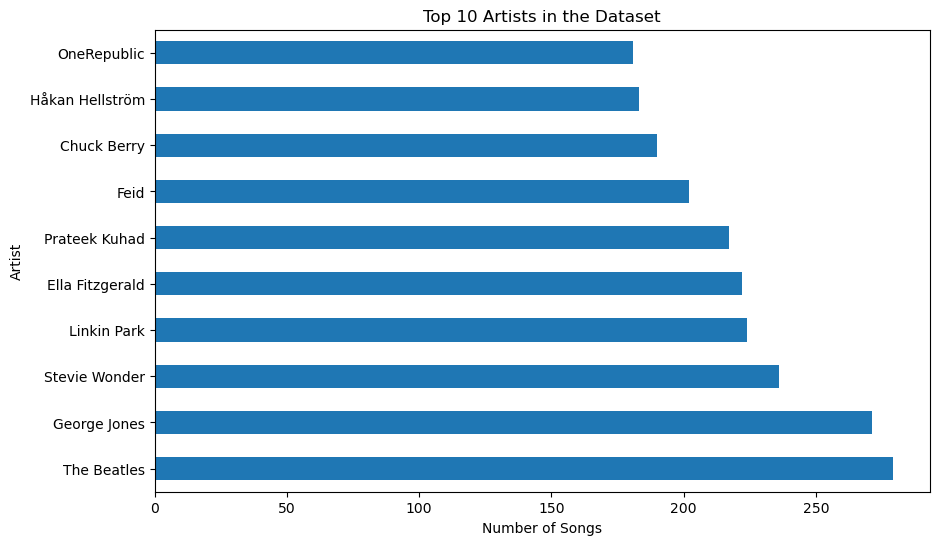

In [ ]:
top_artists = df["artists"].value_counts().head(10)

plt.figure(figsize=(10,6))
top_artists.plot(kind="barh")

plt.title("Top 10 Artists in the Dataset")
plt.xlabel("Number of Songs")
plt.ylabel("Artist")

plt.show()

In [ ]:
df["track_genre"].value_counts().head(10)

track_genre
acoustic             1000
afrobeat             1000
psych-rock           1000
progressive-house    1000
power-pop            1000
pop                  1000
pop-film             1000
piano                1000
party                1000
pagode               1000
Name: count, dtype: int64

In [ ]:
df[["popularity", "energy"]].head(10)

,popularity,energy
0,73,0.4610
1,55,0.1660
2,57,0.3590
3,71,0.0596
4,82,0.4430
5,58,0.4810
6,74,0.1470
7,80,0.4440
8,74,0.4140
9,56,0.6320


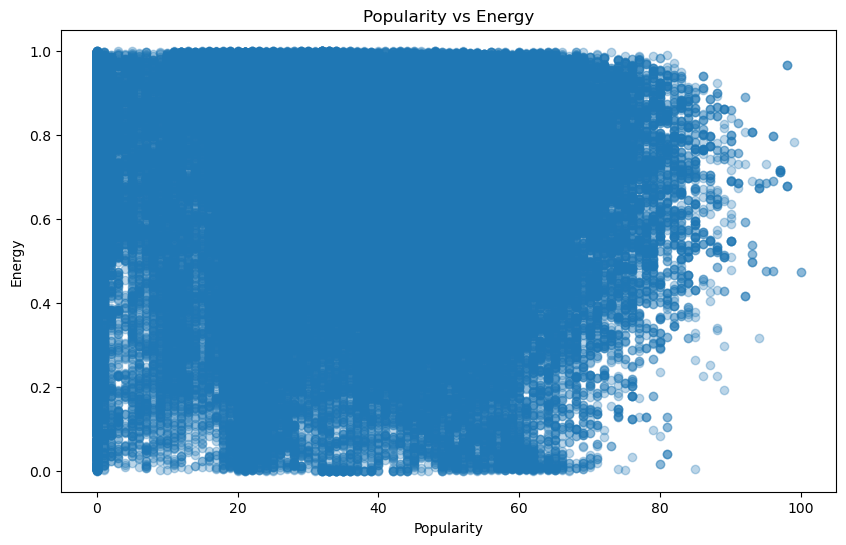

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(df["popularity"], df["energy"], alpha=0.3)

plt.title("Popularity vs Energy")
plt.xlabel("Popularity")
plt.ylabel("Energy")

plt.show()

In [ ]:
df["popularity"].corr(df["energy"])

np.float64(0.0010531126538156847)

In [ ]:
sample = df.sample(5000)

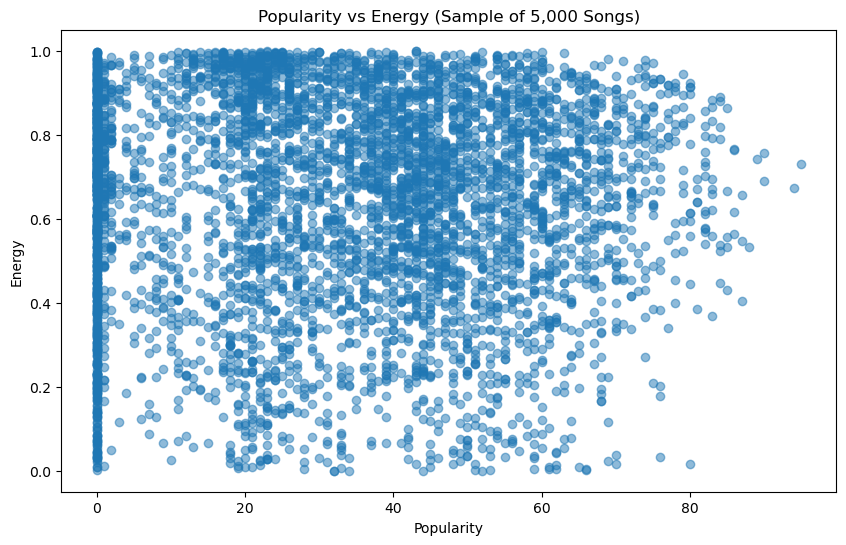

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(sample["popularity"], sample["energy"], alpha=0.5)

plt.title("Popularity vs Energy (Sample of 5,000 Songs)")
plt.xlabel("Popularity")
plt.ylabel("Energy")

plt.show()

## Danceability vs Popularity

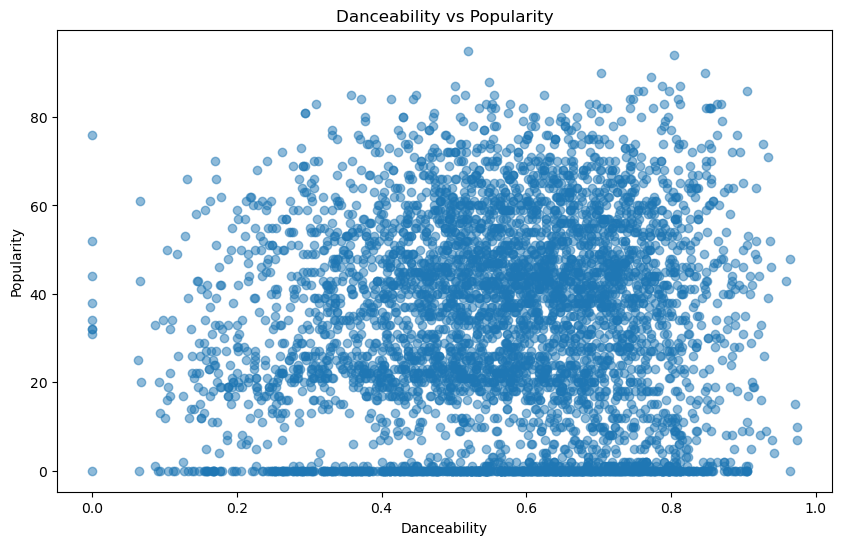

In [ ]:
plt.figure(figsize=(10,6))

plt.scatter(sample["danceability"], sample["popularity"], alpha=0.5)

plt.title("Danceability vs Popularity")
plt.xlabel("Danceability")
plt.ylabel("Popularity")

plt.show()

In [ ]:
df["danceability"].corr(df["popularity"])

np.float64(0.035443545961346)

### Observation

The correlation between danceability and popularity is **0.035**.

This indicates a very weak positive relationship. While songs with higher danceability may be slightly more popular on average, the relationship is too weak to conclude that danceability is a major factor influencing popularity.

In [ ]:
correlations = df.corr(numeric_only=True)["popularity"].sort_values(ascending=False)

correlations

popularity          1.000000
loudness            0.050420
explicit            0.044078
danceability        0.035444
time_signature      0.031076
tempo               0.013212
energy              0.001053
key                -0.003847
liveness           -0.005397
duration_ms        -0.007129
mode               -0.013948
acousticness       -0.025458
valence            -0.040522
speechiness        -0.044930
instrumentalness   -0.095147
Name: popularity, dtype: float64

In [ ]:
genre_popularity = (
    df.groupby("track_genre")["popularity"]
    .mean()
    .sort_values(ascending=False)
)

genre_popularity.head(10)

track_genre
pop-film     59.283000
k-pop        56.952953
chill        53.651000
sad          52.379000
grunge       49.594000
indian       49.539000
anime        48.772000
emo          48.128000
sertanejo    47.866000
pop          47.576000
Name: popularity, dtype: float64

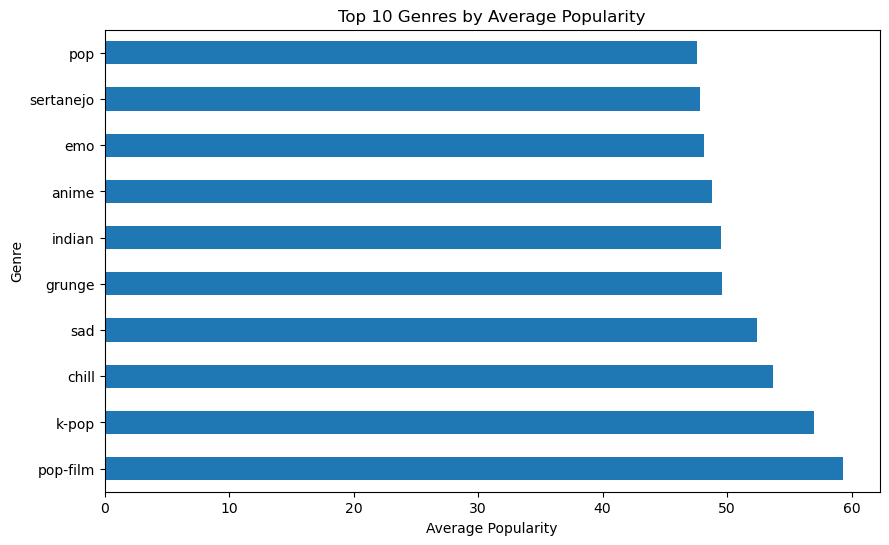

In [ ]:
top_genres = genre_popularity.head(10)

plt.figure(figsize=(10,6))

top_genres.plot(kind="barh")

plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.show()

In [ ]:
df["explicit"].value_counts()

explicit
False    104252
True       9747
Name: count, dtype: int64

In [ ]:
df.groupby("explicit")["popularity"].mean()

explicit
False    32.938207
True     36.454191
Name: popularity, dtype: float64

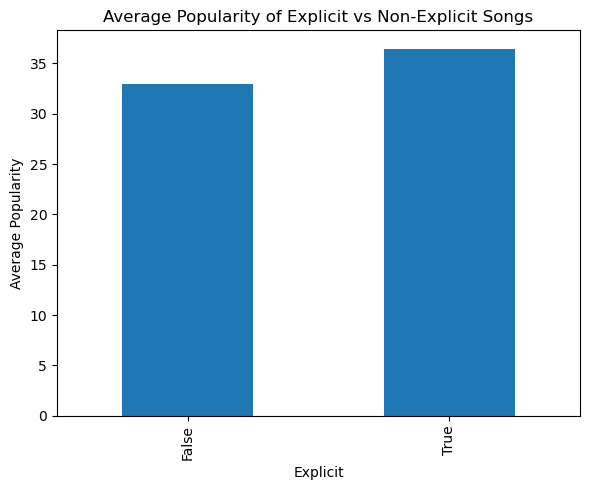

In [ ]:
explicit_popularity = df.groupby("explicit")["popularity"].mean()

ax = explicit_popularity.plot(kind="bar", figsize=(6,5))

ax.set_title("Average Popularity of Explicit vs Non-Explicit Songs")
ax.set_xlabel("Explicit")
ax.set_ylabel("Average Popularity")

plt.tight_layout()

plt.savefig("../visuals/explicit_vs_popularity.png", dpi=300)

plt.show()

In [ ]:
plt.savefig("../visuals/explicit_vs_popularity.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

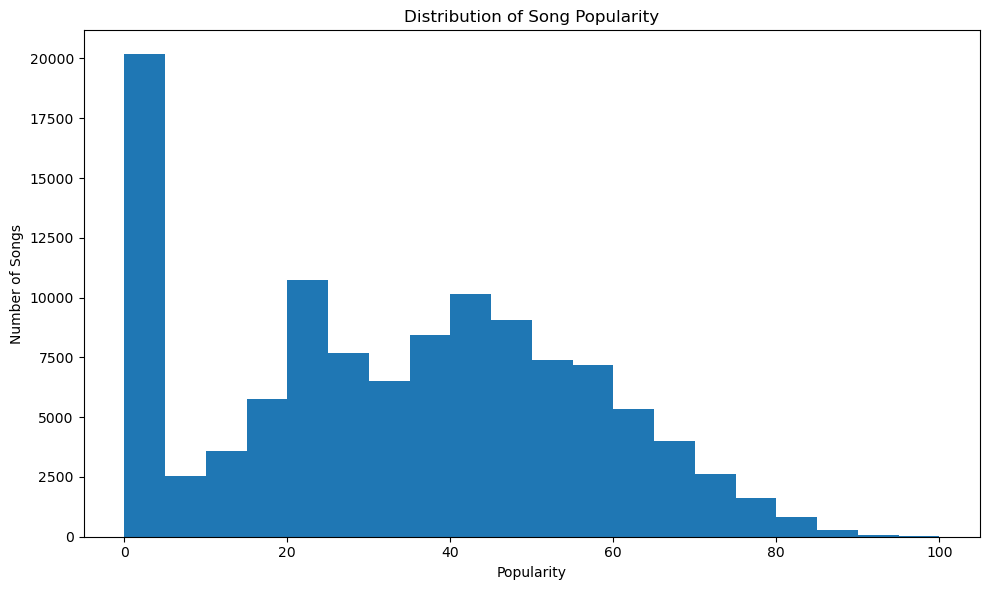

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(df["popularity"], bins=20)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.tight_layout()

plt.savefig("../visuals/popularity_distribution.png", dpi=300)

plt.show()

### Observation

The popularity distribution is right-skewed.

A large number of songs have very low popularity, while most songs fall between popularity scores of 20 and 60.

Only a small number of songs achieve very high popularity (above 80), indicating that highly popular songs are relatively rare in the dataset.

In [ ]:
(df["popularity"] == 0).sum()

np.int64(16019)

In [ ]:
(df["popularity"] == 100).sum()

np.int64(2)

In [ ]:
zero_popularity = (df["popularity"] == 0).sum()
hundred_popularity = (df["popularity"] == 100).sum()

print(f"Zero popularity: {zero_popularity} ({zero_popularity/len(df)*100:.2f}%)")
print(f"Maximum popularity: {hundred_popularity} ({hundred_popularity/len(df)*100:.4f}%)")

Zero popularity: 16019 (14.05%)
Maximum popularity: 2 (0.0018%)


### Additional Observation

Out of **113,999** songs, **16,019** (approximately **14%**) have a popularity score of **0**, while only **2 songs** have the maximum popularity score of **100**.

This indicates that the dataset is heavily concentrated toward lower popularity values. Extremely popular songs are exceptionally rare, suggesting that achieving the highest popularity on Spotify is uncommon. This skewed distribution should be considered when interpreting popularity-related analyses.

## Correlation Heatmap

In [ ]:
corr = df.corr(numeric_only=True)

corr

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
popularity,1.000000,-0.007129,0.044078,0.035444,0.001053,-0.003847,0.050420,-0.013948,-0.044930,-0.025458,-0.095147,-0.005397,-0.040522,0.013212,0.031076
duration_ms,-0.007129,1.000000,-0.065270,-0.073435,0.058520,0.008123,-0.003475,-0.035581,-0.062605,-0.103770,0.124364,0.010308,-0.154464,0.024356,0.018229
explicit,0.044078,-0.065270,1.000000,0.122506,0.096954,0.004485,0.108587,-0.037216,0.307951,-0.094400,-0.103405,0.032547,-0.003378,-0.002815,0.038387
danceability,0.035444,-0.073435,0.122506,1.000000,0.134325,0.036470,0.259076,-0.069224,0.108625,-0.171531,-0.185608,-0.131620,0.477347,-0.050448,0.207219
energy,0.001053,0.058520,0.096954,0.134325,1.000000,0.048007,0.761690,-0.078365,0.142508,-0.733908,-0.181880,0.184795,0.258937,0.247852,0.187127
key,-0.003847,0.008123,0.004485,0.036470,0.048007,1.000000,0.038591,-0.135911,0.020419,-0.040942,-0.006821,-0.001597,0.034099,0.010914,0.015064
loudness,0.050420,-0.003475,0.108587,0.259076,0.761690,0.038591,1.000000,-0.041768,0.060826,-0.589804,-0.433478,0.076897,0.279851,0.212447,0.191992
mode,-0.013948,-0.035581,-0.037216,-0.069224,-0.078365,-0.135911,-0.041768,1.000000,-0.046535,0.095568,-0.049961,0.014004,0.021964,0.000572,-0.024090
speechiness,-0.044930,-0.062605,0.307951,0.108625,0.142508,0.020419,0.060826,-0.046535,1.000000,-0.002184,-0.089617,0.205218,0.036637,0.017274,-0.000011
acousticness,-0.025458,-0.103770,-0.094400,-0.171531,-0.733908,-0.040942,-0.589804,0.095568,-0.002184,1.000000,0.104033,-0.020693,-0.107081,-0.208231,-0.176142


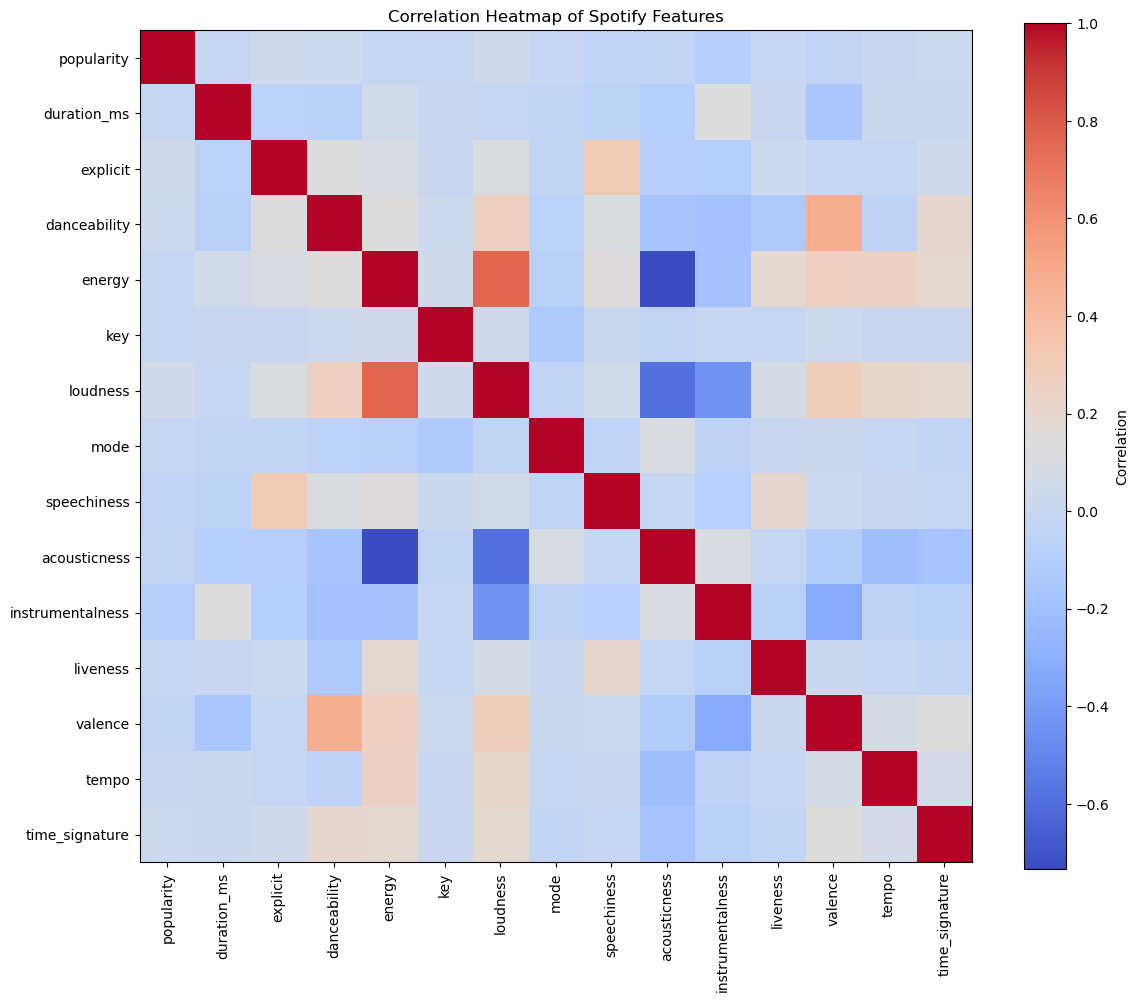

In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")

plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap of Spotify Features")

plt.tight_layout()

plt.savefig("../visuals/correlation_heatmap.png", dpi=300)

plt.show()

## Observation

The correlation heatmap shows that most audio features have only weak relationships with song popularity.

Strong correlations exist between some audio features themselves, such as:

- Energy and Loudness (strong positive)
- Energy and Acousticness (strong negative)
- Danceability and Valence (moderate positive)

However, popularity does not exhibit a strong correlation with any single audio feature, suggesting that song popularity is influenced by multiple factors beyond the characteristics included in this dataset.

In [ ]:
corr_popularity = corr["popularity"].sort_values(ascending=False)

corr_popularity

popularity          1.000000
loudness            0.050420
explicit            0.044078
danceability        0.035444
time_signature      0.031076
tempo               0.013212
energy              0.001053
key                -0.003847
liveness           -0.005397
duration_ms        -0.007129
mode               -0.013948
acousticness       -0.025458
valence            -0.040522
speechiness        -0.044930
instrumentalness   -0.095147
Name: popularity, dtype: float64

In [ ]:
corr_popularity = corr["popularity"].drop("popularity")

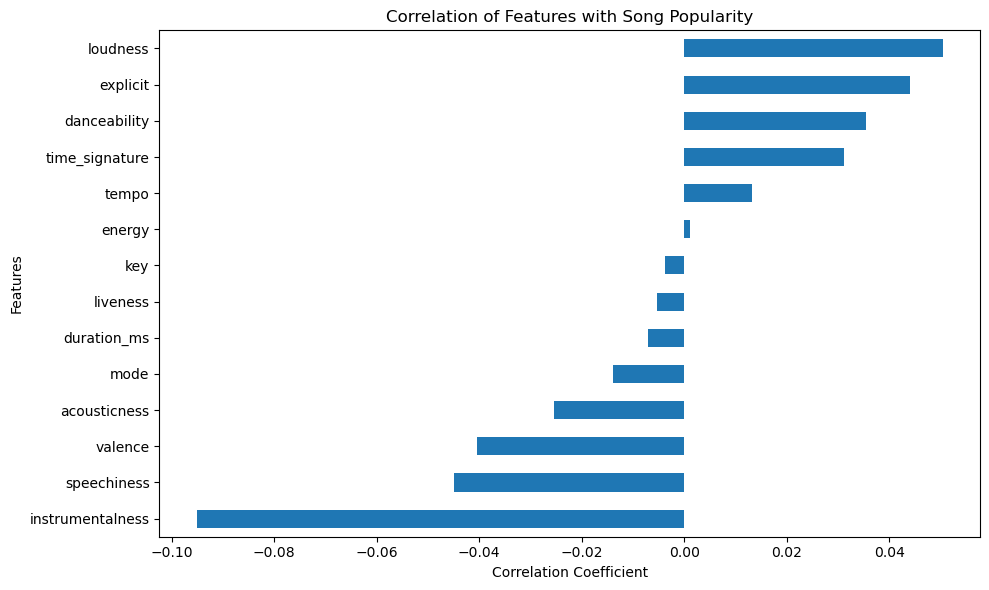

In [ ]:
plt.figure(figsize=(10,6))

corr_popularity.sort_values().plot(kind="barh")

plt.title("Correlation of Features with Song Popularity")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")

plt.tight_layout()

plt.savefig("../visuals/popularity_correlation_ranking.png", dpi=300)

plt.show()

## Observation

Among the audio features, **loudness** shows the highest positive correlation with popularity, while **instrumentalness** shows the strongest negative correlation.

However, all correlation values are relatively close to zero, indicating that no single audio feature strongly predicts a song's popularity. This suggests that popularity is likely influenced by multiple factors beyond the audio characteristics included in this dataset.